# CNN-based Image Enhancement Pipline

Ryan Koes

This notebook is used to explore CNN architectures applied to image enhancement. This is a common approach to this problem and will serve as a baseline result for the transformer and diffusion methods.

In [1]:
import sys
import os
import time
import math
from enum import Enum
from functools import partial

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Dataset
from torch.nn.utils.rnn import pad_sequence
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

from __future__ import annotations

from pathlib import Path
import sys
import os
import subprocess
import textwrap

import matplotlib.pyplot as plt

# Basic configuration
torch.manual_seed(42)
np.random.seed(42)
sns.set_theme(style="whitegrid")

print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.10.0


In [2]:
cpu_device = torch.device("cpu")

# True if *some* accelerator is available (CUDA, MPS, etc.)
has_accel = torch.accelerator.is_available()
print(f"Accelerator available: {has_accel}")

# A torch.device representing the preferred accelerator (if any). If none available, set it to "cpu"
if has_accel:
    accel_device = torch.accelerator.current_accelerator()
    print(f"Preferred accelerator: {accel_device}")
else:
    accel_device = cpu_device
    print("No accelerator available, defaulting to CPU.")

Accelerator available: True
Preferred accelerator: mps


In [3]:
# Turn on the "Auto-Updater"
%load_ext autoreload
%autoreload 2

In [4]:
import wandb

# DO NOT CHANGE THIS:
entity = "bucknell-university-csci357-2026sp"

# DONE: Fill in your name, user id, and email
user_name = "Ryan Koes"
user_initials = "RK"
user_id = "rmk024"
user_email = "rmk024@bucknell.edu"

In [5]:
def _ensure_src_on_path() -> Path:
    """Add the project's `src/` directory to sys.path and return project root."""
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / "src").is_dir():
            sys.path.insert(0, str(p / "src"))
            return p
    raise RuntimeError("Could not find a `src/` directory in current or parent paths")

Project root: /Users/ryankoes/Downloads/Image Enhancement Tool
Path to dataset files: /Users/ryankoes/.cache/kagglehub/datasets/soumikrakshit/div2k-high-resolution-images/versions/1
Train batches: 202 | Val batches: 23


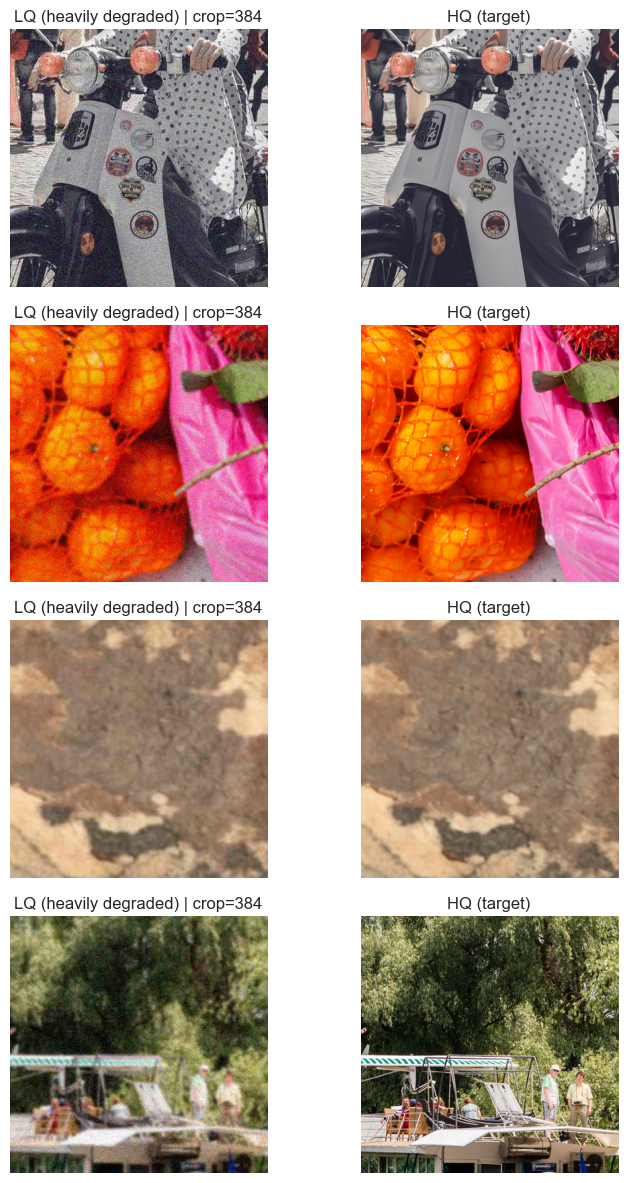

In [6]:
# --- Download DIV2K (HR) from Kaggle and sanity-check the data pipeline ---
from __future__ import annotations

from pathlib import Path
import sys
import os
import subprocess
import textwrap

import matplotlib.pyplot as plt
import torch


project_root = _ensure_src_on_path()
print(f"Project root: {project_root}")

# Import the data utilities you just added
from ml_engine.data import build_dataloader, DegradationPipeline  # noqa: E402


def _run(cmd: list[str]) -> None:
    print("$", " ".join(cmd))
    subprocess.run(cmd, check=True)


def _ensure_kagglehub() -> None:
    """Install `kagglehub` into the current notebook kernel if missing."""
    try:
        import kagglehub  # noqa: F401
        return
    except Exception:
        _run([sys.executable, "-m", "pip", "install", "-q", "kagglehub"])


def _find_any_images(root: Path) -> bool:
    return any(root.rglob("*.png")) or any(root.rglob("*.jpg")) or any(root.rglob("*.jpeg"))


dataset_slug = "soumikrakshit/div2k-high-resolution-images"

# Prefer a local workspace cache if you manually downloaded/extracted already
workspace_cache_dir = project_root / "data" / "kaggle" / "div2k_hr"
workspace_cache_dir.mkdir(parents=True, exist_ok=True)

if _find_any_images(workspace_cache_dir):
    dataset_root = workspace_cache_dir
    print(f"Found existing images in workspace cache: {dataset_root}")
else:
    # Download via kagglehub (handles caching automatically)
    _ensure_kagglehub()
    try:
        import kagglehub
        path = kagglehub.dataset_download(dataset_slug)
        dataset_root = Path(path)
        print("Path to dataset files:", dataset_root)
    except Exception as e:
        raise RuntimeError(
            textwrap.dedent(
                f"""\
                Failed to download dataset via kagglehub: {e}

                You can still proceed by manually downloading and extracting the dataset into:
                {workspace_cache_dir}

                Dataset page: https://www.kaggle.com/datasets/soumikrakshit/div2k-high-resolution-images
                """
            ).strip()
        )

if not _find_any_images(dataset_root):
    raise FileNotFoundError(
        f"No image files found under dataset root: {dataset_root}. "
        "If the dataset extracted into subfolders, set `dataset_root` to the folder that contains the images."
    )

# Heavier degradation preset (stronger than defaults)
degradation = DegradationPipeline(
    p_blur=0.55,
    blur_radius=(0.6, 2.2),
    p_downsample=0.85,
    downsample_scale=(0.25, 0.9),
    p_noise=0.80,
    noise_sigma=(5.0, 25.0),
    p_jpeg=0.85,
    jpeg_quality=(10, 70),
    p_color=0.35,
    brightness=(0.8, 1.15),
    contrast=(0.75, 1.2),
    saturation=(0.75, 1.2),
    gamma=(0.8, 1.2),
)

# Slightly larger crop window
crop_size = 384

train_loader, val_loader = build_dataloader(
    root=dataset_root,
    batch_size=4,
    num_workers=2,
    crop_size=crop_size,
    degradation=degradation,
    normalize=True,
    val_fraction=0.1,
    seed=42,
)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")


@torch.no_grad()
def _denorm(x: torch.Tensor, mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)) -> torch.Tensor:
    """Undo the default [-1,1] normalization for plotting."""
    mean_t = torch.tensor(mean, device=x.device).view(1, -1, 1, 1)
    std_t = torch.tensor(std, device=x.device).view(1, -1, 1, 1)
    x = x * std_t + mean_t
    return x.clamp(0.0, 1.0)


batch = next(iter(train_loader))
lq = batch["lq"]
hq = batch["hq"]

lq_vis = _denorm(lq).cpu()
hq_vis = _denorm(hq).cpu()

# Visualize a few samples: degraded input (LQ) vs target (HQ)
n = min(4, lq_vis.shape[0])
fig, axes = plt.subplots(nrows=n, ncols=2, figsize=(8, 3 * n))
if n == 1:
    axes = [axes]
for i in range(n):
    axes[i][0].imshow(lq_vis[i].permute(1, 2, 0))
    axes[i][0].set_title(f"LQ (heavily degraded) | crop={crop_size}")
    axes[i][0].axis("off")

    axes[i][1].imshow(hq_vis[i].permute(1, 2, 0))
    axes[i][1].set_title("HQ (target)")
    axes[i][1].axis("off")

plt.tight_layout()
plt.show()

In [29]:
# --- Build a simple CNN enhancement baseline ---
from ml_engine.model import EnhancementCNN
from ml_engine.trainer import train_image_to_image, evaluate_image_to_image

device = accel_device
print("Using device:", device)

# Model: small residual CNN (3 -> 3)
model = EnhancementCNN(in_channels=3, out_channels=3, features=64, num_blocks=8, residual=True).to(device)

num_params = sum(p.numel() for p in model.parameters())
print(f"EnhancementCNN params: {num_params:,}")

# Loss (image regression)
loss_fn = torch.nn.L1Loss()

Using device: mps
EnhancementCNN params: 594,371


Baseline input PSNR (LQ→HQ): 22.97 dB
Theoretical max PSNR (HQ→HQ, due to eps clamp): 86.02 dB
Epoch 1/2 | train_loss=0.1035 | val_loss=0.1078 | val_psnr=22.51
Epoch 2/2 | train_loss=0.0917 | val_loss=0.0936 | val_psnr=23.75


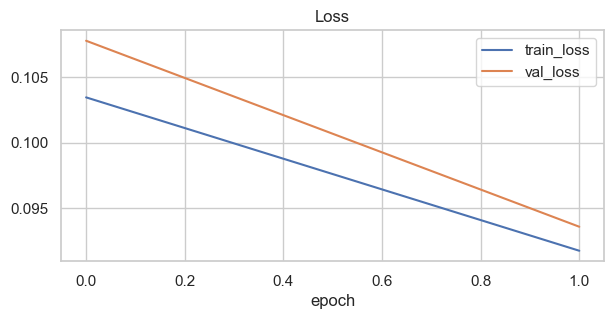

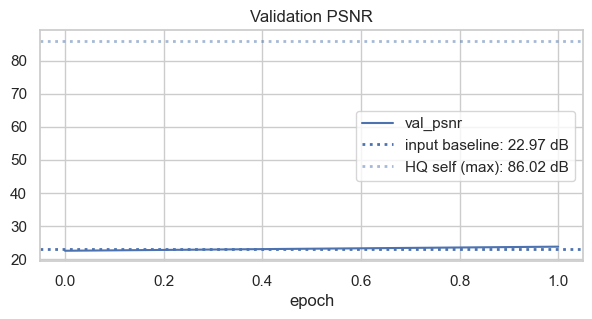

In [30]:
# --- Train (quick sanity run) ---
from ml_engine.trainer import psnr as _psnr

psnr_data_range = 2.0  # because tensors are normalized to [-1, 1]
psnr_eps = 1e-8        # must match eps used in ml_engine.trainer.psnr()

@torch.no_grad()
def baseline_input_psnr(loader, max_batches=50) -> float:
    """PSNR of degraded input (LQ) vs target (HQ), before any model."""
    total = 0.0
    n = 0
    for i, batch in enumerate(loader):
        if max_batches is not None and i >= max_batches:
            break
        lq = batch["lq"].to(device, non_blocking=True)
        hq = batch["hq"].to(device, non_blocking=True)
        total += _psnr(lq, hq, data_range=psnr_data_range, eps=psnr_eps)
        n += 1
    return total / max(1, n)

baseline_psnr = baseline_input_psnr(val_loader, max_batches=50)
perfect_psnr = (20.0 * math.log10(psnr_data_range)) - (10.0 * math.log10(psnr_eps))
print(f"Baseline input PSNR (LQ→HQ): {baseline_psnr:.2f} dB")
print(f"Theoretical max PSNR (HQ→HQ, due to eps clamp): {perfect_psnr:.2f} dB")

epochs = 2
history = train_image_to_image(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    epochs=epochs,
    lr=2e-4,
    weight_decay=0.0,
    loss_fn=loss_fn,
    max_train_batches=200,   # keep runtime reasonable; raise/remove for full training
    max_val_batches=50,
    grad_clip_norm=1.0,
    psnr_data_range=psnr_data_range,
 )

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(history["train_loss"], label="train_loss")
ax.plot(history["val_loss"], label="val_loss")
ax.set_xlabel("epoch")
ax.set_title("Loss")
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(history["val_psnr"], label="val_psnr")
ax.axhline(baseline_psnr, linestyle=":", linewidth=2, label=f"input baseline: {baseline_psnr:.2f} dB")
ax.axhline(perfect_psnr, linestyle=":", linewidth=2, alpha=0.5, label=f"HQ self (max): {perfect_psnr:.2f} dB")
ax.set_xlabel("epoch")
ax.set_title("Validation PSNR")
ax.legend()
plt.show()

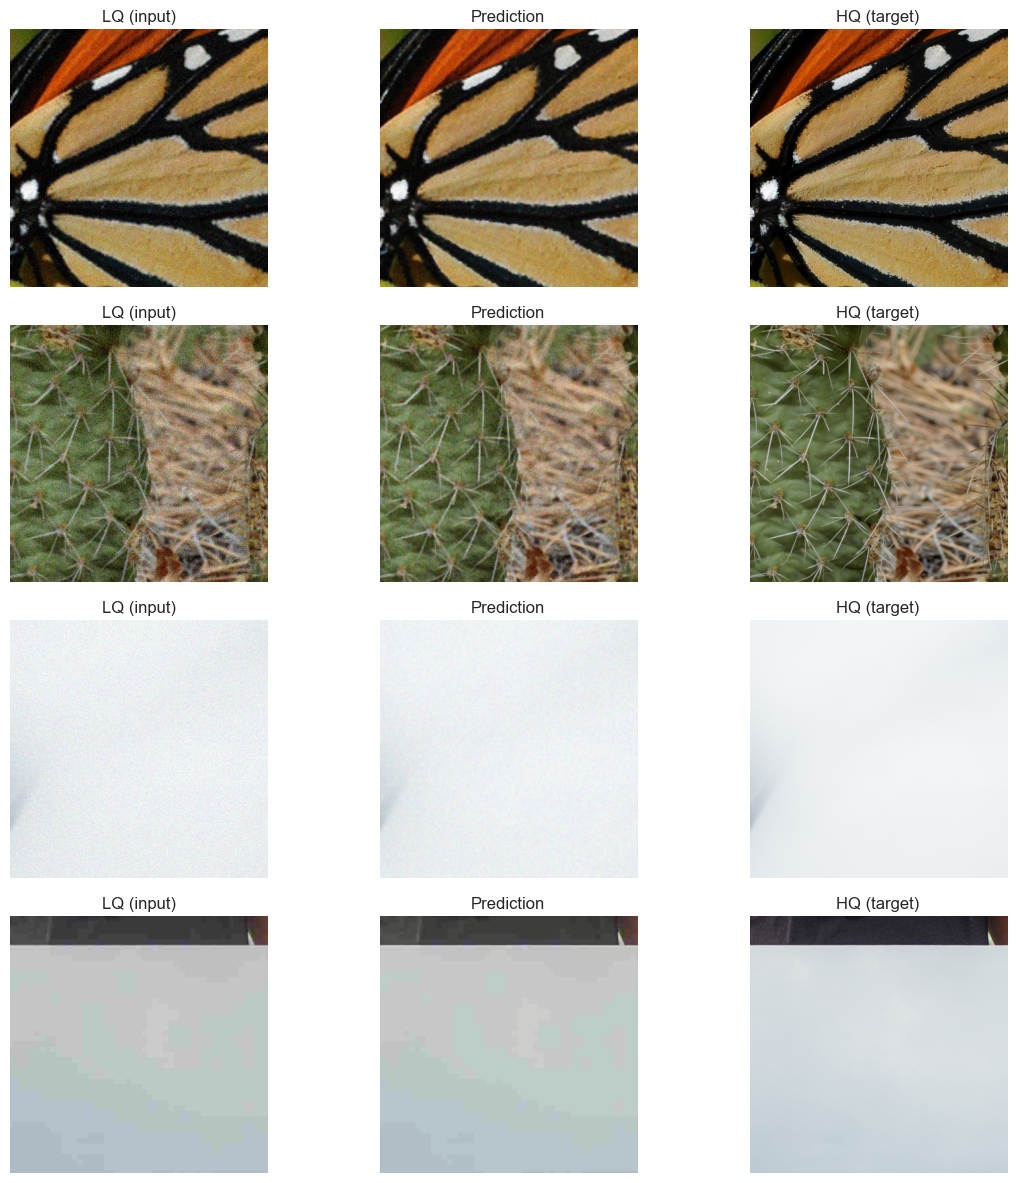

In [27]:
# --- Visualize predictions on a few validation samples ---
model.eval()
batch = next(iter(val_loader))
lq = batch["lq"].to(device)
hq = batch["hq"].to(device)

with torch.no_grad():
    pred = model(lq)

# Convert to display range [0,1] using the helper from Cell 7
lq_vis = _denorm(lq).cpu()
pred_vis = _denorm(pred).cpu()
hq_vis = _denorm(hq).cpu()

n = min(4, lq_vis.shape[0])
fig, axes = plt.subplots(nrows=n, ncols=3, figsize=(12, 3 * n))
if n == 1:
    axes = [axes]
for i in range(n):
    axes[i][0].imshow(lq_vis[i].permute(1, 2, 0))
    axes[i][0].set_title("LQ (input)")
    axes[i][0].axis("off")

    axes[i][1].imshow(pred_vis[i].permute(1, 2, 0))
    axes[i][1].set_title("Prediction")
    axes[i][1].axis("off")

    axes[i][2].imshow(hq_vis[i].permute(1, 2, 0))
    axes[i][2].set_title("HQ (target)")
    axes[i][2].axis("off")

plt.tight_layout()
plt.show()

In [33]:
# --- Quick validation metrics snapshot ---
metrics = evaluate_image_to_image(
    model=model,
    loader=val_loader,
    loss_fn=loss_fn,
    device=device,
    max_batches=50,
    psnr_data_range=2.0,
)
print(metrics)

{'loss': 0.10566673800349236, 'psnr': 22.831901882005774}


In [ ]:
# --- W&B logging toggle (optional) ---
import wandb

USE_WANDB = False  # set True to log runs / sweeps to Weights & Biases
WANDB_PROJECT = "cnn-image-enhancement"
WANDB_ENTITY = entity  # from the earlier cell (course entity)

if USE_WANDB:
    # Prompts in browser if needed, otherwise uses existing login
    wandb.login()

# For sweeps: where to save the best local checkpoint across runs
SWEEP_CKPT_DIR = project_root / "checkpoints" / "enhancement_sweep"
SWEEP_CKPT_DIR.mkdir(parents=True, exist_ok=True)

print(f"USE_WANDB={USE_WANDB}")

In [ ]:
# --- Define a sweep config for the enhancement CNN ---
import numpy as np

# Track best model across sweep runs (in this kernel session)
BEST = {"val_psnr": -1e9, "ckpt": None, "config": None}

sweep_config = {
    "method": "random",
    "metric": {"name": "val_psnr", "goal": "maximize"},
    "parameters": {
        # Model size knobs
        "features": {"values": [32, 48, 64]},
        "num_blocks": {"values": [4, 6, 8, 10]},
        "residual": {"values": [True]},
        # Optimization
        "lr": {"distribution": "log_uniform_values", "min": 1e-5, "max": 5e-4},
        "weight_decay": {"values": [0.0, 1e-6, 1e-5]},
        "epochs": {"values": [10]},
        "max_val_batches": {"values": [25, 50]},
    },
}

print("Sweep config ready.")

In [ ]:
# --- Sweep train function (uses the engine) ---
from ml_engine.model import EnhancementCNN
from ml_engine.trainer import train_image_to_image, evaluate_image_to_image

def _wandb_log_fn():
    # wandb.log wants step as int; we log each epoch.
    def _log(payload: dict[str, float]) -> None:
        wandb.log({
            "train_loss": payload["train_loss"],
            "val_loss": payload["val_loss"],
            "val_psnr": payload["val_psnr"],
            "epoch": int(payload["epoch"]),
        }, step=int(payload["epoch"]))
    return _log

def sweep_train_one_run() -> None:
    cfg = wandb.config
    run_name = (
        f"enh_cnn_f{cfg.features}_b{cfg.num_blocks}_lr{cfg.lr:.1e}_wd{cfg.weight_decay:.1e}"
    )
    wandb.run.name = run_name

    # Allow max_train_batches to be omitted from sweep_config (=> full epoch)
    max_train_batches = getattr(cfg, "max_train_batches", None)
    if max_train_batches is not None:
        max_train_batches = int(max_train_batches)

    # Build model from sweep config
    m = EnhancementCNN(
        in_channels=3,
        out_channels=3,
        features=int(cfg.features),
        num_blocks=int(cfg.num_blocks),
        residual=bool(cfg.residual),
    ).to(device)

    # Train with optional W&B logging per epoch
    history = train_image_to_image(
        model=m,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        epochs=int(cfg.epochs),
        lr=float(cfg.lr),
        weight_decay=float(cfg.weight_decay),
        loss_fn=loss_fn,
        max_train_batches=max_train_batches,
        max_val_batches=int(cfg.max_val_batches),
        grad_clip_norm=1.0,
        psnr_data_range=psnr_data_range,
        log_fn=_wandb_log_fn(),
    )

    # Final metrics snapshot (log as summary)
    metrics = evaluate_image_to_image(
        model=m,
        loader=val_loader,
        loss_fn=loss_fn,
        device=device,
        max_batches=int(cfg.max_val_batches),
        psnr_data_range=psnr_data_range,
    )
    wandb.log({"val_loss_final": metrics["loss"], "val_psnr_final": metrics["psnr"]})
    wandb.run.summary["val_loss"] = metrics["loss"]
    wandb.run.summary["val_psnr"] = metrics["psnr"]

    # Save best checkpoint locally for later visualization in this notebook session
    ckpt_path = SWEEP_CKPT_DIR / f"{wandb.run.id}.pt"
    torch.save({
        "model_state_dict": m.state_dict(),
        "config": dict(cfg),
        "val_psnr": float(metrics["psnr"]),
        "val_loss": float(metrics["loss"]),
    }, ckpt_path)

    if float(metrics["psnr"]) > float(BEST["val_psnr"]):
        BEST["val_psnr"] = float(metrics["psnr"])
        BEST["ckpt"] = str(ckpt_path)
        BEST["config"] = dict(cfg)
        print("New BEST:", BEST["val_psnr"], "dB", "->", BEST["ckpt"])

In [ ]:
# --- Run the sweep (optional) ---
RUN_SWEEP = False  # set True to run the sweep
SWEEP_COUNT = 8     # number of runs to launch
if RUN_SWEEP:
    if not USE_WANDB:
        raise RuntimeError("Set USE_WANDB=True before running a W&B sweep.")
    sweep_id = wandb.sweep(sweep_config, project=WANDB_PROJECT, entity=WANDB_ENTITY)
    print("Sweep ID:", sweep_id)
    wandb.agent(sweep_id, function=sweep_train_one_run, count=SWEEP_COUNT)
else:
    print("Sweep not started. Set RUN_SWEEP=True to run it.")

In [ ]:
# --- Load the best sweep checkpoint (if any) and visualize ---
from ml_engine.model import EnhancementCNN

if BEST["ckpt"] is None:
    print("No sweep checkpoints recorded yet. Run the sweep cell first, or just use the current `model`.")
else:
    ckpt = torch.load(BEST["ckpt"], map_location=device)
    cfg = ckpt.get("config", {})
    best_model = EnhancementCNN(
        in_channels=3,
        out_channels=3,
        features=int(cfg.get("features", 64)),
        num_blocks=int(cfg.get("num_blocks", 8)),
        residual=bool(cfg.get("residual", True)),
    ).to(device)
    best_model.load_state_dict(ckpt["model_state_dict"])
    best_model.eval()

    batch = next(iter(val_loader))
    lq = batch["lq"].to(device)
    hq = batch["hq"].to(device)
    with torch.no_grad():
        pred = best_model(lq)

    lq_vis = _denorm(lq).cpu()
    pred_vis = _denorm(pred).cpu()
    hq_vis = _denorm(hq).cpu()

    n = min(4, lq_vis.shape[0])
    fig, axes = plt.subplots(nrows=n, ncols=3, figsize=(12, 3 * n))
    if n == 1:
        axes = [axes]
    for i in range(n):
        axes[i][0].imshow(lq_vis[i].permute(1, 2, 0))
        axes[i][0].set_title("LQ (input)")
        axes[i][0].axis("off")

        axes[i][1].imshow(pred_vis[i].permute(1, 2, 0))
        axes[i][1].set_title(f"Best sweep pred ({BEST['val_psnr']:.2f} dB)")
        axes[i][1].axis("off")

        axes[i][2].imshow(hq_vis[i].permute(1, 2, 0))
        axes[i][2].set_title("HQ (target)")
        axes[i][2].axis("off")

    plt.tight_layout()
    plt.show()